# Importing the Libraries 


Gerekli kütüphanelerin yüklenmesi: (Kullanılan veya kullanılabilecek kütüphaneler):


![Numpy](https://img.shields.io/badge/Numpy%20-%20%23013243?style=for-the-badge&logo=numpy)
![Igraph](https://img.shields.io/badge/Igraph%20-%20%23F7A41D?style=for-the-badge)
![Matplotlib](https://img.shields.io/badge/Matplotlib%20-%20%230054FF?style=for-the-badge)



In [14]:
import igraph as ig
import matplotlib.pyplot as plt
import numpy as np

# Reading The Network Set File and Fundamental Verification


Esas analizler öncesinde dosya okuma ve veri setindeki attributeların (İsim, index, id vb) kontrolü, herhangi bir eksikliğin olup olmadığı ve veri
setinin simple, multiple edge ve loop durumları incelenmiştir ve doğrulanmıştır

In [15]:
MV = ig.Graph.Read_GraphML("marvel_universe.graphml")


print("The Summary: ", MV.summary()) # A summarization for the network set


#*
# Analyzing whether vertices and edges have attributes or not 
# *#
print("The Vertex Attribute(s): ", MV.vs.attribute_names()) 
print("The Edge Attribute(s): ", MV.es.attribute_names())

# Other analysis such as Order, Size, Directed, Weighted etc
print("Number of vertices:", MV.vcount()) # Order
print("Number of edges:", MV.ecount()) # Size
print("Directed:", MV.is_directed()) # (The network set is undirected based on the output)
print("Weighted:", "weight" in MV.es.attribute_names())
print("Simple graph:", MV.is_simple())
print("Self-loop count:", sum(MV.is_loop()))
print("Multiple-edge pairs:", sum(MV.is_multiple()))



# Checking for characters in the set
# Vertex attributes are the names and ids. Therefore, we use them as attributes
print("The Characters (first 20)")
print("Index -- ID -- Name of the character")
for v in MV.vs[:20]:
    print(v.index, v['id'], v['name'])

print("---------------------------------------------------------------------------------")

# Missing Name Analysis
names = MV.vs["name"] # Extracting the names 

missing_names = [
    v.index
    for v in MV.vs
    if v["name"] is None or str(v["name"]).strip() == ""
]

print("Missing character names:", len(missing_names))
print("Unique names:", len(set(names)))
print("Total names:", len(names))

print("---------------------------------------------------------------------------------")
# Checking for duplications (names)
from collections import Counter

name_counts = Counter(names)

duplicate_names = {
    name: count
    for name, count in name_counts.items()
    if count > 1
}

print("Number of duplicated name values:", len(duplicate_names))

for name, count in list(duplicate_names.items())[:20]:
    print(name, count)


The Summary:  IGRAPH UN-- 19428 95497 -- marvel_universe
+ attr: citation (g), description (g), name (g), url (g), id (v), name (v), id (e)
The Vertex Attribute(s):  ['name', 'id']
The Edge Attribute(s):  ['id']
Number of vertices: 19428
Number of edges: 95497
Directed: False
Weighted: False
Simple graph: True
Self-loop count: 0
Multiple-edge pairs: 0
The Characters (first 20)
Index -- ID -- Name of the character
0 n0 24-HOUR MAN/EMMANUEL
1 n1 3-D MAN/CHARLES CHAN
2 n2 4-D MAN/MERCURIO
3 n3 8-BALL/
4 n4 A
5 n5 A'YIN
6 n6 ABBOTT, JACK
7 n7 ABCISSA
8 n8 ABEL
9 n9 ABOMINATION/EMIL BLO
10 n10 ABOMINATION | MUTANT
11 n11 ABOMINATRIX
12 n12 ABRAXAS
13 n13 ADAM 3,031
14 n14 ABSALOM
15 n15 ABSORBING MAN/CARL C
16 n16 ABSORBING MAN | MUTA
17 n17 ACBA
18 n18 ACHEBE, REVEREND DOC
19 n19 ACHILLES
---------------------------------------------------------------------------------
Missing character names: 1
Unique names: 19293
Total names: 19428
--------------------------------------------------------

# Basic Network Statistics


Bu kısımda **Order**,**Size**, **Density** vb metriklerin analizi yapılmaktadır

In [16]:
print("=" * 50)
print("NETWORK STATISTICS")
print("=" * 50)

# Order & Size
num_vertices = MV.vcount()
num_edges = MV.ecount()

print("Number of vertices (Order): ", num_vertices)
print("Number of edges (Size): ", num_edges)

# Density
density = MV.density()
print("Density: ", density)

# Average Degree
avg_degree = np.mean(MV.degree())
print("Average Degree: ", avg_degree)

# Calculating manually the average to check if they're equal or not
avg_degree_man = 2 * MV.ecount() / MV.vcount()
is_same = avg_degree == avg_degree_man
print("Is the result of auto and manuel same for average degree: ", is_same)

# Minimum and Maximum Degree
degrees = MV.degree()

print("Minimum Degree: ", min(degrees))
print("Maximum Degree: ", max(degrees))

# Isolated vertices
isolated = len(MV.vs.select(_degree=0))
print("Number of Isolated Vertices: ", isolated)

NETWORK STATISTICS
Number of vertices (Order):  19428
Number of edges (Size):  95497
Density:  0.0005060412144145541
Average Degree:  9.830862672431541
Is the result of auto and manuel same for average degree:  True
Minimum Degree:  0
Maximum Degree:  1625
Number of Isolated Vertices:  177


# Degree Distribution Analysis

Average Degree:  9.830862672431541
Median Degree:  5.0
Max Degree:  1625
Min Degree:  0
Degree -- Number of Vertices
0 177
1 3371
2 2117
3 1719
4 1472
5 1431
6 1250
7 1049
8 985
9 828
10 699
11 607
12 555
13 451
14 347
15 286
16 234
17 215
18 197
19 151


Top 10 Characters by Degree
--------------------------------
SPIDER-MAN/PETER PAR 1625
CAPTAIN AMERICA 1367
IRON MAN/TONY STARK  1168
THING/BENJAMIN J. GR 990
THOR/DR. DONALD BLAK 965
HUMAN TORCH/JOHNNY S 908
MR. FANTASTIC/REED R 875
HULK/DR. ROBERT BRUC 841
WOLVERINE/LOGAN  820
INVISIBLE WOMAN/SUE  782


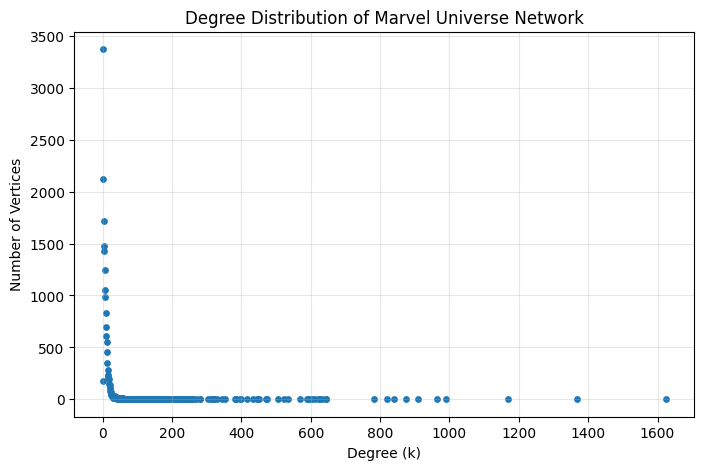

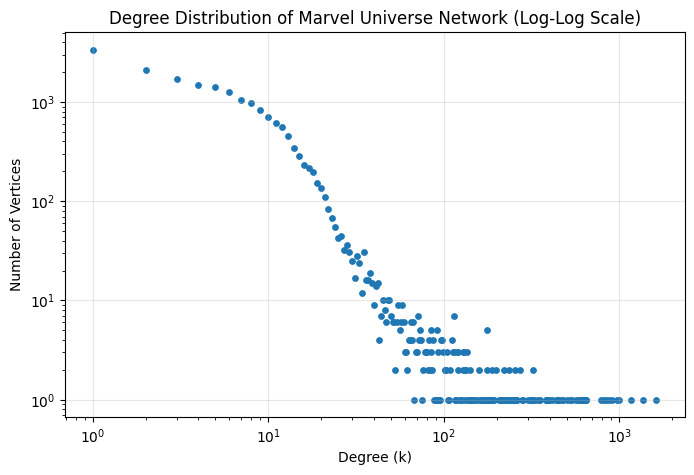

In [4]:
degrees = MV.degree()

print("Average Degree: ", np.mean(degrees))
print("Median Degree: ", np.median(degrees))
print("Max Degree: ", max(degrees))
print("Min Degree: ", min(degrees))


from collections import Counter

degree_counts = Counter(degrees)

degree_values = sorted(degree_counts.keys())
frequencies = [degree_counts[k] for k in degree_values]

print("Degree -- Number of Vertices")

for k in degree_values[:20]:
    print(k, degree_counts[k])

degree_info = [
    (v["name"], v.degree())
    for v in MV.vs
]

degree_info.sort(key=lambda x: x[1], reverse=True)

print("\n")
print("Top 10 Characters by Degree")
print("--------------------------------")

for name, degree in degree_info[:10]:
    print(name, degree)



# Normal Plot
plt.figure(figsize=(8, 5))

plt.scatter(degree_values, frequencies, s=15)

plt.xlabel("Degree (k)")
plt.ylabel("Number of Vertices")
plt.title("Degree Distribution of Marvel Universe Network")

plt.grid(alpha=0.3)
plt.show()


# Log - Log Plot
plt.figure(figsize=(8, 5))

plt.scatter(degree_values, frequencies, s=15)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Degree (k)")
plt.ylabel("Number of Vertices")
plt.title("Degree Distribution of Marvel Universe Network (Log-Log Scale)")

plt.grid(alpha=0.3)
plt.show()

# Clustering Analysis

Local ve Global Clustering analizleri

Triangles: 0
Global Clustering Coefficient (Transitivity): 0.0
Average Local Clustering Coefficient: 0.0
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Number of non-zero local clustering values: 0
Minimum Local Clustering: 0.0
Maximum Local Clustering: 0.0
Average Local Clustering: 0.0
Spider-Man degree: 1625
Edges among Spider-Man's neighbors: 0


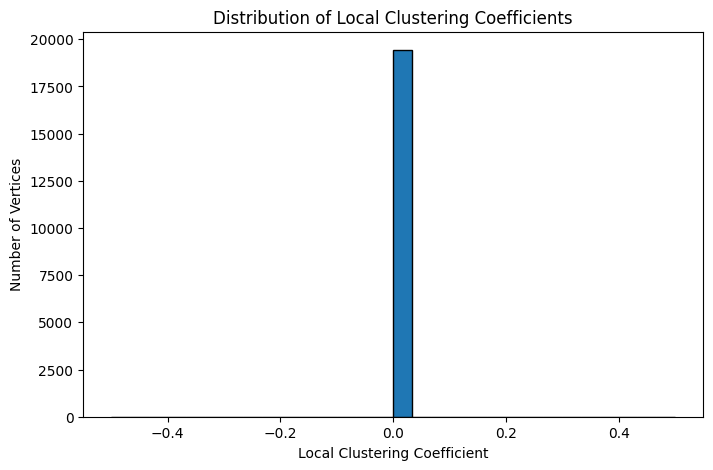

In [17]:
print("Triangles:", len(MV.list_triangles()))


global_clustering = MV.transitivity_undirected()

print("Global Clustering Coefficient (Transitivity):", global_clustering)

#*
# Bu kısımda mode olarak zero'yu seçtik
# Önceki analizlerde isolated nodelar olduğunu görmüştük bu nedenle tanımsız olmaması için mode'u zero olarak seçtik ve ortalamada 0 olacaklar
# *#
avg_local_clustering = MV.transitivity_avglocal_undirected(mode="zero")

print("Average Local Clustering Coefficient:", avg_local_clustering)


local_clustering = MV.transitivity_local_undirected(mode="zero")


print(local_clustering[:20])
print("Number of non-zero local clustering values:",
      sum(c > 0 for c in local_clustering))
print("Minimum Local Clustering:", min(local_clustering))
print("Maximum Local Clustering:", max(local_clustering))
print("Average Local Clustering:", np.mean(local_clustering))


spider = MV.vs.find(name="SPIDER-MAN/PETER PAR")

neighbors = MV.neighbors(spider.index)

spider_neighborhood = MV.induced_subgraph(neighbors)

print("Spider-Man degree:", spider.degree())
print("Edges among Spider-Man's neighbors:",
      spider_neighborhood.ecount())

plt.figure(figsize=(8, 5))

plt.hist(local_clustering, bins=30, edgecolor="black")

plt.xlabel("Local Clustering Coefficient")
plt.ylabel("Number of Vertices")
plt.title("Distribution of Local Clustering Coefficients")

plt.show()

# Component Size Distribution

Component büyüklerinin analizi ve dağılımı

Num of connected components:  201
The Largest Component Size:  19182
The Smallest Component Size:  1
-----------------------
Top 10 Component Sizes:
[19182, 11, 8, 5, 4, 3, 3, 3, 2, 2]
Giant Component Ratio: 0.9873378628783199
Giant Component Percentage: 98.73378628783199
-----------------------
Giant Component
Vertices: 19182
Edges: 95445
Percentage of all vertices: 98.73378628783199
-----------------------
Component Size -- Number of Components
1 177
2 16
3 3
4 1
5 1
8 1
11 1
19182 1


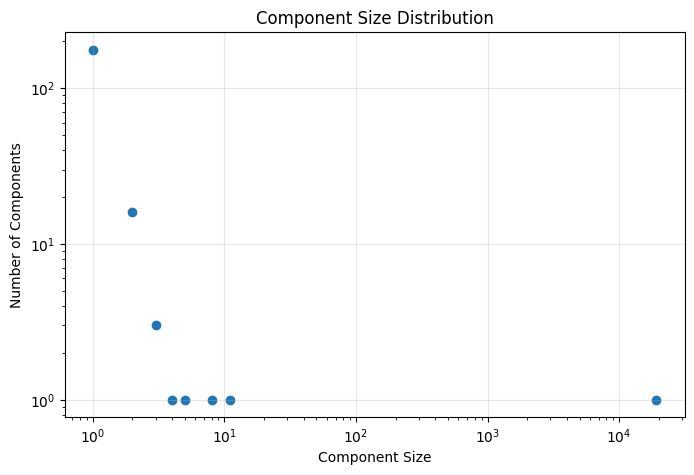

In [18]:
components = MV.connected_components()
print("Num of connected components: ", len(components))


# Component Büyüklük analizleri
component_sizes = components.sizes()
largest_component_size = max(component_sizes)
smallest_component_size = min(component_sizes)

print("The Largest Component Size: ", largest_component_size)
print("The Smallest Component Size: ", smallest_component_size)
print("-----------------------")
print("Top 10 Component Sizes:")
print(sorted(component_sizes, reverse=True)[:10])

# Giant Component Analizi
largest_component_size = max(component_sizes)

giant_component_ratio = largest_component_size / MV.vcount()

print("Giant Component Ratio:", giant_component_ratio)
print("Giant Component Percentage:",
      giant_component_ratio * 100)
print("-----------------------")
# Giant Component Ayrı Analizi
giant = components.giant()

print("Giant Component")

print("Vertices:", giant.vcount())
print("Edges:", giant.ecount())
print("Percentage of all vertices:",
      giant.vcount() / MV.vcount() * 100)





#--------------------------------------------------------------
# Component Size Analizi (Esas)
from collections import Counter

component_size_counts = Counter(component_sizes)
print("-----------------------")
print("Component Size -- Number of Components")

for size in sorted(component_size_counts):
    print(size, component_size_counts[size])

sizes = sorted(component_size_counts.keys())
counts = [component_size_counts[size] for size in sizes]

# Component Distribution Plot
plt.figure(figsize=(8, 5))

plt.scatter(sizes, counts)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Component Size")
plt.ylabel("Number of Components")
plt.title("Component Size Distribution")

plt.grid(alpha=0.3)
plt.show()


# Centrality Analysis

Bu kısımda degree, betweenness, harmonic ve eigenvector centrality analizleri yapılmıştır

## Part 1

Bu kısımda ayrı ayrı analiz yapılmıştır

In [7]:
# Degree
degrees = MV.degree()

# Betweenness
betweenness = MV.betweenness(directed=False)

betweenness_info = [
    (MV.vs[i]["name"], betweenness[i])
    for i in range(MV.vcount())
]

betweenness_info.sort(key=lambda x: x[1], reverse=True)

print("Top 5 Characters by Betweenness")
print("----------------------------------")

for name, value in betweenness_info[:5]:
    print(name, value)

# Harmonic
harmonic = MV.harmonic_centrality()

harmonic_info = [
    (MV.vs[i]["name"], harmonic[i])
    for i in range(MV.vcount())
]

print("\n")
harmonic_info.sort(key=lambda x: x[1], reverse=True)

print("Top 5 Characters by Harmonic Centrality")
print("------------------------------------------")

for name, value in harmonic_info[:5]:
    print(name, value)

print("\n")
# Eigenvector 
giant = MV.connected_components().giant()

eigenvector = giant.eigenvector_centrality()

eigenvector_info = [
    (giant.vs[i]["name"], eigenvector[i])
    for i in range(giant.vcount())
]

eigenvector_info.sort(key=lambda x: x[1], reverse=True)

print("Top 5 Characters by Eigenvector Centrality")
print("------------------------------------------")
for name, value in eigenvector_info[:5]:
    print(name, value)

Top 5 Characters by Betweenness
----------------------------------
SPIDER-MAN/PETER PAR 28536642.55361339
CAPTAIN AMERICA 18784385.49360245
IRON MAN/TONY STARK  12784496.99574914
HULK/DR. ROBERT BRUC 10707731.062331073
THOR/DR. DONALD BLAK 9928725.78771255


Top 5 Characters by Harmonic Centrality
------------------------------------------
COC 1 0.398407959467219
H2 279 0.3906464248332911
M/GN 1 0.3819116497166773
IW 3 0.3782340238302687
IW 2 0.3778882850817913


Top 5 Characters by Eigenvector Centrality
------------------------------------------
CAPTAIN AMERICA 1.0
THING/BENJAMIN J. GR 0.7986336202368642
IRON MAN/TONY STARK  0.7891358373906254
HUMAN TORCH/JOHNNY S 0.7725399322036495
MR. FANTASTIC/REED R 0.7551888982752651


In [8]:
for name, value in harmonic_info[:5]:
    v = MV.vs.find(name=name)

    print(
        "Name:", name,
        "| ID:", v["id"],
        "| Degree:", v.degree(),
        "| Harmonic:", value
    )

membership = MV.connected_components().membership
components = MV.connected_components()

for name, value in harmonic_info[:5]:
    v = MV.vs.find(name=name)

    component_id = membership[v.index]
    component_size = len(components[component_id])

    print(
        name,
        "| Degree:", v.degree(),
        "| Component Size:", component_size,
        "| Harmonic:", value
    )

Name: COC 1 | ID: n6495 | Degree: 111 | Harmonic: 0.398407959467219
Name: H2 279 | ID: n7108 | Degree: 87 | Harmonic: 0.3906464248332911
Name: M/GN 1 | ID: n7560 | Degree: 59 | Harmonic: 0.3819116497166773
Name: IW 3 | ID: n7699 | Degree: 91 | Harmonic: 0.3782340238302687
Name: IW 2 | ID: n7694 | Degree: 76 | Harmonic: 0.3778882850817913
COC 1 | Degree: 111 | Component Size: 19182 | Harmonic: 0.398407959467219
H2 279 | Degree: 87 | Component Size: 19182 | Harmonic: 0.3906464248332911
M/GN 1 | Degree: 59 | Component Size: 19182 | Harmonic: 0.3819116497166773
IW 3 | Degree: 91 | Component Size: 19182 | Harmonic: 0.3782340238302687
IW 2 | Degree: 76 | Component Size: 19182 | Harmonic: 0.3778882850817913


## Part 2

Bu kısımda ayrıca bir ortak fonksiyon yardımıyla centrality analizi yapıyoruz

In [9]:
def top_characters(values, n=10):
    indices = sorted(
        range(len(values)),
        key=lambda i: values[i],
        reverse=True
    )[:n]

    return [
        (MV.vs[i]["name"], values[i])
        for i in indices
    ]


print("DEGREE")
print(top_characters(degrees))

print("\nBETWEENNESS")
print(top_characters(betweenness))

print("\nHARMONIC")
print(top_characters(harmonic))

print("\nEIGENVECTOR")
print(top_characters(eigenvector))

DEGREE
[('SPIDER-MAN/PETER PAR', 1625), ('CAPTAIN AMERICA', 1367), ('IRON MAN/TONY STARK ', 1168), ('THING/BENJAMIN J. GR', 990), ('THOR/DR. DONALD BLAK', 965), ('HUMAN TORCH/JOHNNY S', 908), ('MR. FANTASTIC/REED R', 875), ('HULK/DR. ROBERT BRUC', 841), ('WOLVERINE/LOGAN ', 820), ('INVISIBLE WOMAN/SUE ', 782)]

BETWEENNESS
[('SPIDER-MAN/PETER PAR', 28536642.55361339), ('CAPTAIN AMERICA', 18784385.49360245), ('IRON MAN/TONY STARK ', 12784496.99574914), ('HULK/DR. ROBERT BRUC', 10707731.062331073), ('THOR/DR. DONALD BLAK', 9928725.78771255), ('WOLVERINE/LOGAN ', 9627601.773378173), ('DR. STRANGE/STEPHEN ', 9195742.281956205), ('DAREDEVIL/MATT MURDO', 8412697.685456999), ('THING/BENJAMIN J. GR', 7609430.057894746), ('COC 1', 6308193.627177132)]

HARMONIC
[('COC 1', 0.398407959467219), ('H2 279', 0.3906464248332911), ('M/GN 1', 0.3819116497166773), ('IW 3', 0.3782340238302687), ('IW 2', 0.3778882850817913), ('H2 278', 0.37786695982754426), ('SPIDER-MAN/PETER PAR', 0.3770888331653684), ('CA

# Community Detection

Community Analizleri burada yapılmıştır (Giant Component üzerinden analizi yapıyoruz yoksatatmin edecek bir sonuç vermeyebilir)

Number of Communities: 46
Modularity: 0.6912084979430587
Largest Community Size: 2964
Smallest Community Size: 3
Top 10 Community Sizes:
[2964, 2920, 1990, 1657, 1387, 975, 903, 761, 679, 643]
Community Size -- Number of Communities
3 1
4 1
5 1
6 2
8 3
9 2
11 1
14 1
15 1
16 1
20 1
24 1
25 1
39 1
48 1
58 1
63 1
118 1
150 1
155 1
159 1
167 1
180 1
190 1
200 1
224 1
251 1
255 1
355 1
438 1
470 1
592 1
643 1
679 1
761 1
903 1
975 1
1387 1
1657 1
1990 1
2920 1
2964 1

Community 1
Size: 2964
First 20 Characters:
A
A'YIN
ABCISSA
ABEL
ABSALOM
ADVERSARY
AGEE, DR. AUBREY
AGEE, REBECCA
AHAB/RORY CAMPBELL
AI-CHIA
AINET
ALBERT
ALCHEMY/THOMAS JONES
ALEGRIA, RICHIE
ALFY
ALVAREZ, CARLY
AMINEDI
AMPHIBIUS
ANAIS
ANDERSON, CHIEF MAGI

Community 2
Size: 2920
First 20 Characters:
24-HOUR MAN/EMMANUEL
ABRAXAS
ADAM 3,031
AIR WALKER/ARLO SAMU
AIRBORNE/
ALANYA
ALBERIK
ALBUQUERQUE, JEREMIA
ALDEN, PROF. MEREDIT
ALIOTH
ALVAREZ, FELIX
AMENHOTEP
AMPERE/
ANAMI, HIROSHI
ANCESTOR/
ANDERSON, CHET
ANDERSON, MARJORIE
ANDE

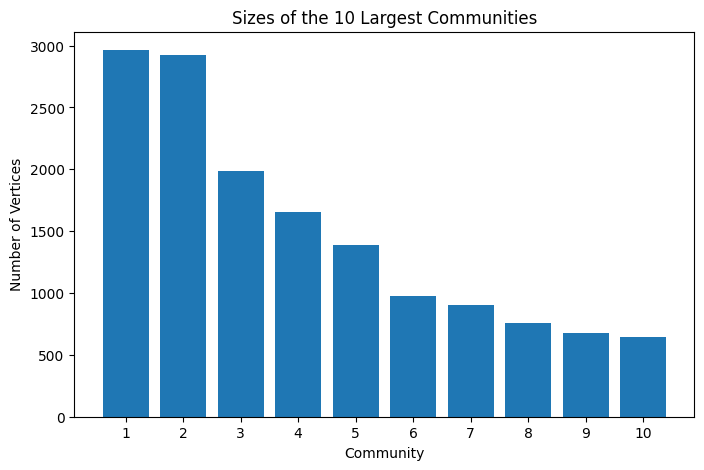

In [13]:
# Community Detection using Leiden Algorithm
import random


giant = MV.connected_components().giant()
random.seed(42)
ig.set_random_number_generator(random)
communities = giant.community_leiden(
    objective_function="modularity"
)

print("Number of Communities:", len(communities))
print("Modularity:", communities.modularity)

community_sizes = communities.sizes()

print("Largest Community Size:", max(community_sizes))
print("Smallest Community Size:", min(community_sizes))

print("Top 10 Community Sizes:")
print(sorted(community_sizes, reverse=True)[:10])

# Community Count
from collections import Counter

community_size_counts = Counter(community_sizes)

print("Community Size -- Number of Communities")

for size in sorted(community_size_counts):
    print(size, community_size_counts[size])

# Community's Character Analysis
sorted_communities = sorted(
    communities,
    key=len,
    reverse=True
)

for i, community in enumerate(sorted_communities[:5], start=1):

    members = [
        giant.vs[v]["name"]
        for v in community
    ]

    print(f"\nCommunity {i}")
    print("Size:", len(community))
    print("First 20 Characters:")

    for name in members[:20]:
        print(name)

for i, community in enumerate(sorted_communities[:5], start=1):

    members = [
        (
            giant.vs[v]["name"],
            giant.degree(v)
        )
        for v in community
    ]

    members.sort(
        key=lambda x: x[1],
        reverse=True
    )

    print(f"\nCommunity {i}")
    print("Size:", len(community))
    print("Top 10 Characters by Degree:")

    for name, degree in members[:10]:
        print(name, degree)


# Plotting of Communities
top_community_sizes = sorted(communities.sizes(), reverse=True)[:10]

plt.figure(figsize=(8, 5))

plt.bar(
    range(1, 11),
    top_community_sizes
)

plt.xlabel("Community")
plt.ylabel("Number of Vertices")
plt.title("Sizes of the 10 Largest Communities")

plt.xticks(range(1, 11))
plt.show()


# Community Visualization

Vertices: 100
Edges: 0


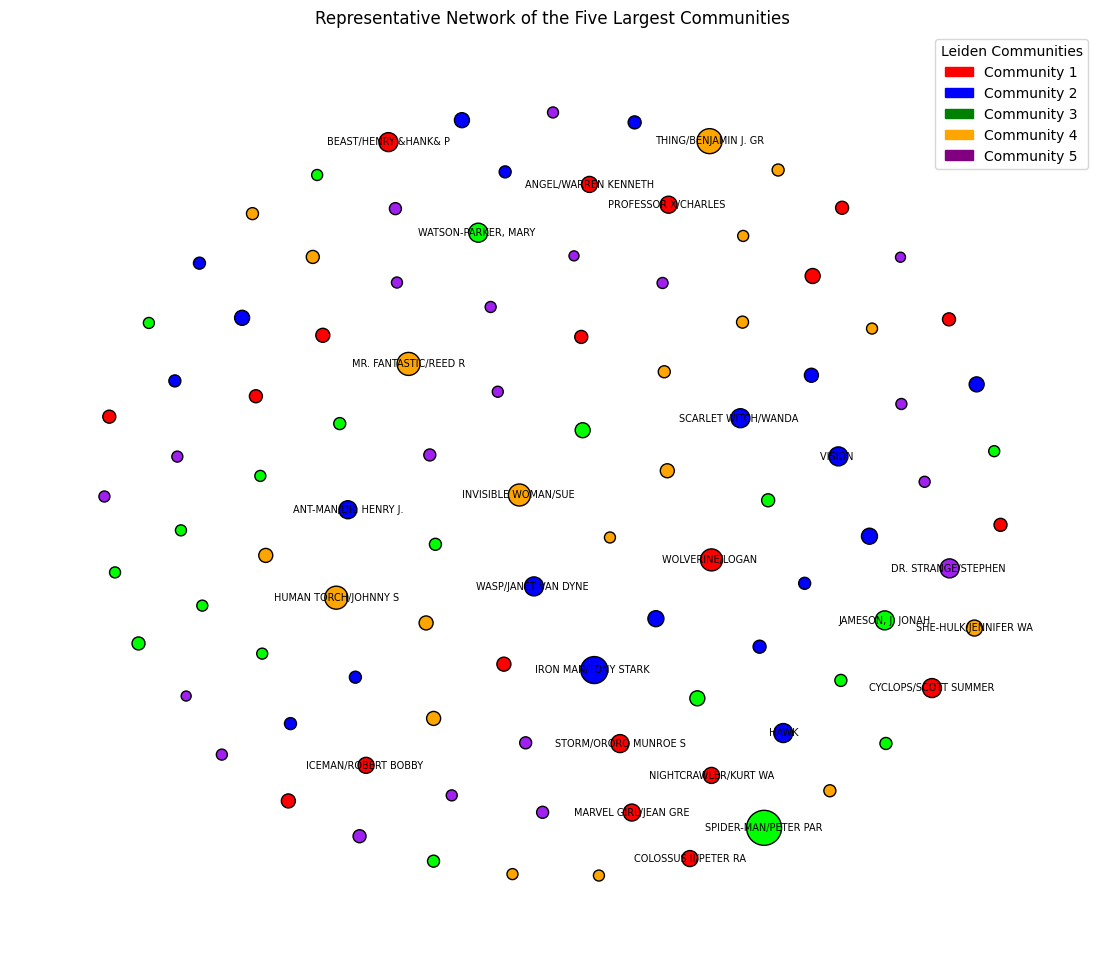

In [ ]:
# ============================================================
# COMMUNITY VISUALIZATION
#
# Representing 5 largest communites (It would be hard to plot the one who is the entire graph)
# ============================================================


import matplotlib.patches as mpatches

# Store original degree and community membership using the giant component
giant.vs["original_degree"] = giant.degree()
giant.vs["community"] = communities.membership

# Sort communities by size
community_ids = sorted(
    range(len(communities)),
    key=lambda i: len(communities[i]),
    reverse=True
)

top_5_community_ids = community_ids[:5]

# Select top 20 highest-degree vertices from each community
selected_vertices = []

for community_id in top_5_community_ids:

    members = list(communities[community_id])

    members_sorted = sorted(
        members,
        key=lambda v: giant.vs[v]["original_degree"],
        reverse=True
    )

    selected_vertices.extend(members_sorted[:20])

# Create subgraph
community_subgraph = giant.induced_subgraph(selected_vertices)

print("Vertices:", community_subgraph.vcount())
print("Edges:", community_subgraph.ecount())

# ------------------------------------------------------------
# Vertex sizes
# ------------------------------------------------------------

original_degrees = community_subgraph.vs["original_degree"]
max_degree = max(original_degrees)

vertex_sizes = [
    10 + (degree / max_degree) * 25
    for degree in original_degrees
]

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

vertex_labels = [
    v["name"] if v["original_degree"] >= 400 else ""
    for v in community_subgraph.vs
]

# ------------------------------------------------------------
# Explicit colors for communities
# ------------------------------------------------------------

palette = [
    "red",
    "blue",
    "green",
    "orange",
    "purple"
]

community_map = {
    community_id: i
    for i, community_id in enumerate(top_5_community_ids)
}

vertex_colors = [
    palette[community_map[v["community"]]]
    for v in community_subgraph.vs
]

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

layout = community_subgraph.layout_fruchterman_reingold(
    niter=1000
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 12))

ig.plot(
    community_subgraph,
    target=ax,
    layout=layout,

    vertex_size=vertex_sizes,
    vertex_color=vertex_colors,
    vertex_label=vertex_labels,
    vertex_label_size=7,

    edge_width=1.2,
    edge_color="lightgray"
)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

legend_labels = [
    "Community 1",
    "Community 2",
    "Community 3",
    "Community 4",
    "Community 5"
]

legend_handles = [
    mpatches.Patch(
        color=palette[i],
        label=legend_labels[i]
    )
    for i in range(5)
]

ax.legend(
    handles=legend_handles,
    title="Leiden Communities",
    loc="upper right"
)

plt.title(
    "Representative Network of the Five Largest Communities"
)

plt.show()

Little Sample for a Marvel Network Graph

Vertices: 31
Edges: 30


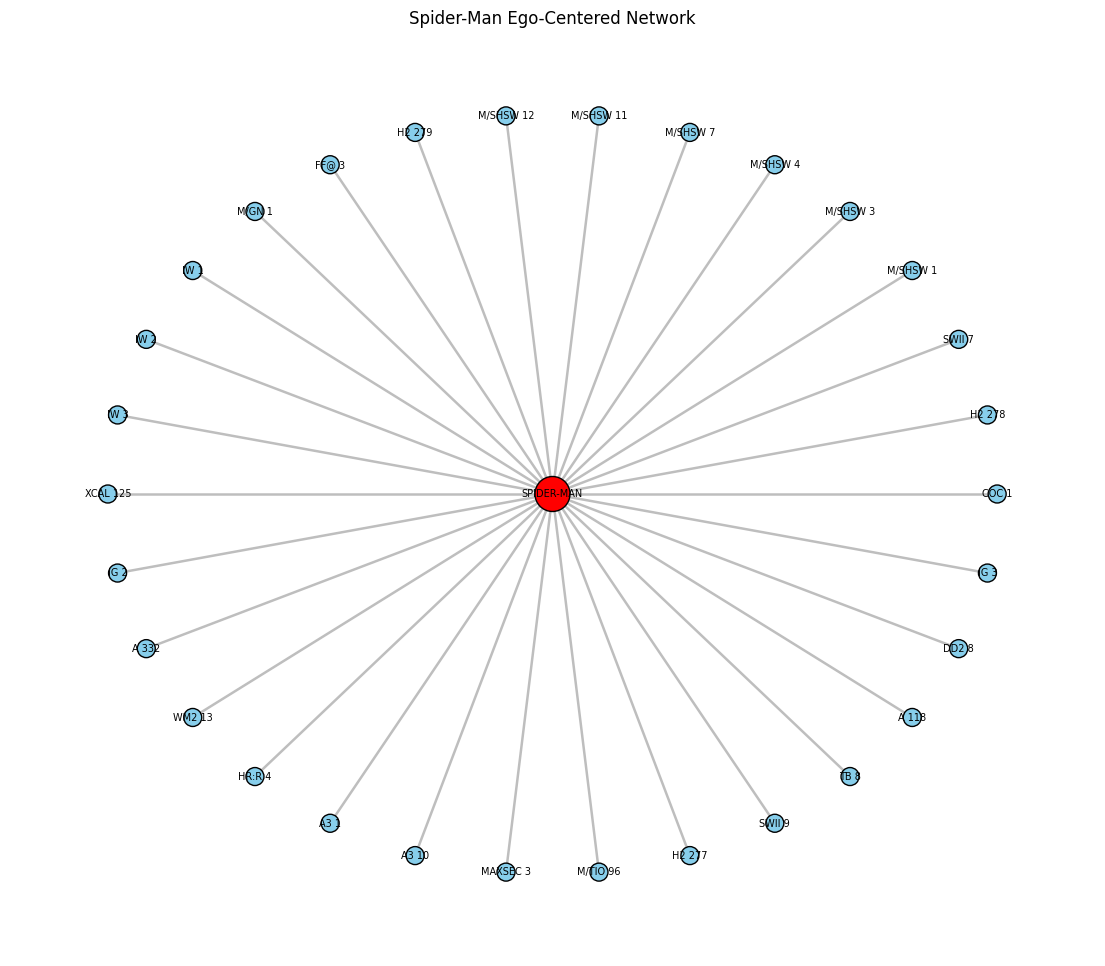

In [148]:
# ============================================================
# SPIDER-MAN EGO-CENTERED NETWORK
# ============================================================

import igraph as ig
import matplotlib.pyplot as plt

# Store original degree values
MV.vs["original_degree"] = MV.degree()

# Find Spider-Man
spiderman = MV.vs.find(name="SPIDER-MAN/PETER PAR")

# Get Spider-Man's neighbors
neighbors = MV.neighbors(spiderman.index)

# Select the 30 highest-degree neighbors
top_neighbors = sorted(
    neighbors,
    key=lambda v: MV.vs[v]["original_degree"],
    reverse=True
)[:30]

# Include Spider-Man
selected_vertices = [spiderman.index] + top_neighbors

# Create ego-centered subgraph
spider_ego = MV.induced_subgraph(selected_vertices)

print("Vertices:", spider_ego.vcount())
print("Edges:", spider_ego.ecount())

# ------------------------------------------------------------
# Identify Spider-Man inside the subgraph
# ------------------------------------------------------------

spider_sub_index = spider_ego.vs.find(
    name="SPIDER-MAN/PETER PAR"
).index

# ------------------------------------------------------------
# Vertex sizes
# ------------------------------------------------------------

vertex_sizes = []

for v in spider_ego.vs:
    if v.index == spider_sub_index:
        vertex_sizes.append(35)
    else:
        vertex_sizes.append(18)

# ------------------------------------------------------------
# Vertex colors
# ------------------------------------------------------------

vertex_colors = []

for v in spider_ego.vs:
    if v.index == spider_sub_index:
        vertex_colors.append("red")
    else:
        vertex_colors.append("skyblue")

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

vertex_labels = []

for v in spider_ego.vs:
    if v.index == spider_sub_index:
        vertex_labels.append("SPIDER-MAN")
    else:
        vertex_labels.append(v["name"])

# ------------------------------------------------------------
# Layout
# Star layout works well for an ego network
# ------------------------------------------------------------

layout = spider_ego.layout_star(center=spider_sub_index)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 12))

ig.plot(
    spider_ego,
    target=ax,
    layout=layout,
    vertex_size=vertex_sizes,
    vertex_color=vertex_colors,
    vertex_label=vertex_labels,
    vertex_label_size=7,
    edge_width=1.8,
    edge_color="gray"
)

plt.title("Spider-Man Ego-Centered Network")

plt.show()